# 🏙️ Intel Scene Classification — EfficientNetB0 Fine-Tuning
### Transfer Learning Pipeline · 6 Classes · ~25,000 Images

| Class | Description |
|-------|-------------|
| 🏢 buildings | Urban Buildings |
| 🌲 forest | Forest |
| 🧊 glacier | Glacier |
| ⛰️ mountain | Mountain |
| 🌊 sea | Sea / Ocean |
| 🛣️ street | Street Scene |

**Pipeline:** Auto-download via kagglehub → tf.data augmentation → Two-phase fine-tuning → Full evaluation

In [1]:
# Install required packages
# kagglehub: no JSON key needed — opens browser for one-time Kaggle login
!pip install kagglehub tensorflow scikit-learn seaborn matplotlib -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import os
import shutil
import logging
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model

# Logger
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  [%(levelname)s]  %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger('IntelSceneFineTuner')

# Constants
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
CLASS_DESCRIPTIONS = {
    'buildings': 'Urban Buildings',
    'forest'   : 'Forest',
    'glacier'  : 'Glacier',
    'mountain' : 'Mountain',
    'sea'      : 'Sea',
    'street'   : 'Street',
}
KAGGLE_DATASET_ID = 'puneet6060/intel-image-classification'

print('✅ Imports done  |  TF version:', tf.__version__)
print('🖥️  GPU:', tf.config.list_physical_devices('GPU') or 'Not detected — using CPU')

✅ Imports done  |  TF version: 2.18.0
🖥️  GPU: Not detected — using CPU


c:\Users\HELAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## ⚙️ Configuration
All hyperparameters in one place. Edit here before running.

In [3]:
@dataclass
class Config:
    """
    Centralised configuration for the Intel Scene fine-tuning pipeline.

    Attributes
    ----------
    data_root      : Directory where dataset is downloaded and organised.
    output_dir     : Destination for models, logs, and visualisation artefacts.
    img_size       : Spatial input dimensions.  EfficientNetB0 default = 224x224.
    batch_size     : Samples per gradient update step.
    phase1_epochs  : Epochs for head-only training (backbone frozen).
    phase2_epochs  : Additional epochs for fine-tuning unfrozen layers.
    phase1_lr      : Learning rate Phase 1 (fresh layers -> higher LR safe).
    phase2_lr      : Learning rate Phase 2 (pre-trained -> tiny LR required).
    dropout_rate   : Fraction of units dropped for regularisation.
    dense_units    : Neurons in the intermediate Dense layer.
    unfreeze_last  : Number of backbone tail layers to unlock in Phase 2.
    """
    data_root     : str   = 'intel_data'
    output_dir    : str   = 'outputs'
    img_size      : tuple = (224, 224)
    batch_size    : int   = 32
    phase1_epochs : int   = 15
    phase2_epochs : int   = 15
    phase1_lr     : float = 1e-3
    phase2_lr     : float = 1e-5
    dropout_rate  : float = 0.40
    dense_units   : int   = 256
    unfreeze_last : int   = 30

    @property
    def input_shape(self): return (*self.img_size, 3)

    @property
    def num_classes(self): return len(CLASSES)

    @property
    def train_dir(self): return str(Path(self.data_root) / 'train')

    @property
    def val_dir(self):   return str(Path(self.data_root) / 'val')

    def save(self, path):
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, 'w') as f: json.dump(asdict(self), f, indent=4)
        logger.info('Config saved -> %s', path)

    @classmethod
    def load(cls, path):
        with open(path) as f: return cls(**json.load(f))


# ── Instantiate config here — edit values as needed ──
config = Config(
    data_root     = 'intel_data',
    output_dir    = 'outputs',
    img_size      = (224, 224),
    batch_size    = 32,
    phase1_epochs = 15,
    phase2_epochs = 15,
    phase1_lr     = 1e-3,
    phase2_lr     = 1e-5,
    dropout_rate  = 0.40,
    dense_units   = 256,
    unfreeze_last = 30,
)

Path(config.output_dir).mkdir(parents=True, exist_ok=True)
config.save(f'{config.output_dir}/config.json')
print('✅ Config ready:', config)

2026-02-22 03:02:32  [INFO]  Config saved -> outputs/config.json


✅ Config ready: Config(data_root='intel_data', output_dir='outputs', img_size=(224, 224), batch_size=32, phase1_epochs=15, phase2_epochs=15, phase1_lr=0.001, phase2_lr=1e-05, dropout_rate=0.4, dense_units=256, unfreeze_last=30)


## 📥 Dataset Download & Organisation
kagglehub downloads automatically. First run opens a browser for Kaggle login — **one-time only, no JSON key needed.**

In [4]:
class DatasetDownloader:
    """
    Downloads Intel Image Classification dataset via kagglehub
    and organises it into train / val sub-folders by class.

    kagglehub caches downloads in ~/.cache/kagglehub/
    so subsequent calls are instant.
    """

    def __init__(self, config: Config):
        self.config = config
        self.root   = Path(config.data_root)

    def setup(self, force: bool = False) -> 'DatasetDownloader':
        if self._is_ready() and not force:
            logger.info("Dataset ready at '%s' — skipping download.", self.config.data_root)
            return self
        raw_path = self._download()
        self._organise(raw_path)
        return self

    def _is_ready(self) -> bool:
        for split in ['train', 'val']:
            p = self.root / split
            if not p.exists() or not any(p.iterdir()): return False
        return True

    def _download(self) -> Path:
        try:
            import kagglehub
        except ImportError:
            raise ImportError('Run:  !pip install kagglehub')
        logger.info('Downloading Intel Scene dataset via kagglehub ...')
        logger.info('(first run opens a browser for one-time Kaggle login)')
        raw = kagglehub.dataset_download(KAGGLE_DATASET_ID)
        logger.info('Download complete — cached at: %s', raw)
        return Path(raw)

    def _organise(self, raw_path: Path) -> None:
        """Map seg_train -> train/,  seg_test -> val/"""
        split_map = {'seg_train': self.config.train_dir,
                     'seg_test' : self.config.val_dir}
        for kaggle_split, dest_split in split_map.items():
            candidates = list(raw_path.rglob(kaggle_split))
            src_dir = None
            for c in candidates:
                inner = c / kaggle_split
                src_dir = inner if inner.exists() else c
                if src_dir.exists(): break
            if src_dir is None or not src_dir.exists():
                logger.warning("Could not locate '%s'", kaggle_split)
                continue
            dest = Path(dest_split)
            if dest.exists(): shutil.rmtree(dest)
            shutil.copytree(src_dir, dest)
            imgs = sum(1 for _ in dest.rglob('*.jpg'))
            logger.info('Organised %s -> %s  (%d images)', kaggle_split, dest_split, imgs)
        logger.info('Dataset organisation complete.')


downloader = DatasetDownloader(config)
downloader.setup()
print('✅ Dataset ready')

2026-02-22 03:02:32  [INFO]  Downloading Intel Scene dataset via kagglehub ...
2026-02-22 03:02:32  [INFO]  (first run opens a browser for one-time Kaggle login)


ConnectionError: HTTPSConnectionPool(host='www.kaggle.com', port=443): Max retries exceeded with url: /api/v1/datasets/view/puneet6060/intel-image-classification (Caused by NameResolutionError("HTTPSConnection(host='www.kaggle.com', port=443): Failed to resolve 'www.kaggle.com' ([Errno 11001] getaddrinfo failed)"))

## 🔄 Data Pipeline
`tf.data` pipeline with GPU-accelerated augmentation and prefetching.

In [ ]:
class SceneDataModule:
    """
    Builds high-performance tf.data input pipelines.

    Augmentation (training only):
        Random flip, brightness, contrast, hue, saturation, zoom.
    Validation: normalise only.
    """
    AUTOTUNE = tf.data.AUTOTUNE

    def __init__(self, config: Config):
        self.config      = config
        self._train_ds   = None
        self._val_ds     = None
        self._class_names: list = []

    def setup(self) -> 'SceneDataModule':
        self._train_ds, self._class_names = self._build(self.config.train_dir, augment=True,  shuffle=True)
        self._val_ds,   _                 = self._build(self.config.val_dir,   augment=False, shuffle=False)
        logger.info('Data module ready — classes: %s', self._class_names)
        return self

    @property
    def train(self): return self._train_ds

    @property
    def val(self): return self._val_ds

    @property
    def class_names(self): return self._class_names

    def _build(self, directory, augment, shuffle):
        ds = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size  = self.config.img_size,
            batch_size  = self.config.batch_size,
            label_mode  = 'categorical',
            shuffle     = shuffle,
            seed        = 42,
            class_names = CLASSES,
        )
        class_names = ds.class_names
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                    num_parallel_calls=self.AUTOTUNE)
        if augment:
            ds = ds.map(self._augment, num_parallel_calls=self.AUTOTUNE)
        return ds.cache().prefetch(self.AUTOTUNE), class_names

    @staticmethod
    def _augment(imgs, lbls):

        def augment_image(img):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, max_delta=0.15)
            img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
            img = tf.image.random_hue(img, max_delta=0.05)
            img = tf.image.random_saturation(img, lower=0.8, upper=1.2)

            h = tf.shape(img)[0]
            w = tf.shape(img)[1]

            ch = tf.cast(tf.cast(h, tf.float32) * tf.random.uniform([], 0.85, 1.0), tf.int32)
            cw = tf.cast(tf.cast(w, tf.float32) * tf.random.uniform([], 0.85, 1.0), tf.int32)

            img = tf.image.random_crop(img, size=[ch, cw, 3])
            img = tf.image.resize(img, [h, w])

            return tf.clip_by_value(img, 0.0, 1.0)

        imgs = tf.map_fn(augment_image, imgs)
        return imgs, lbls


data = SceneDataModule(config)
data.setup()
print('✅ Datasets ready')
print('   Train batches :', sum(1 for _ in data.train))
print('   Val   batches :', sum(1 for _ in data.val))

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


2026-02-22 02:13:30  [INFO]  Data module ready — classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


✅ Datasets ready
   Train batches : 439
   Val   batches : 94


## 🖼️ Visualise Training Samples

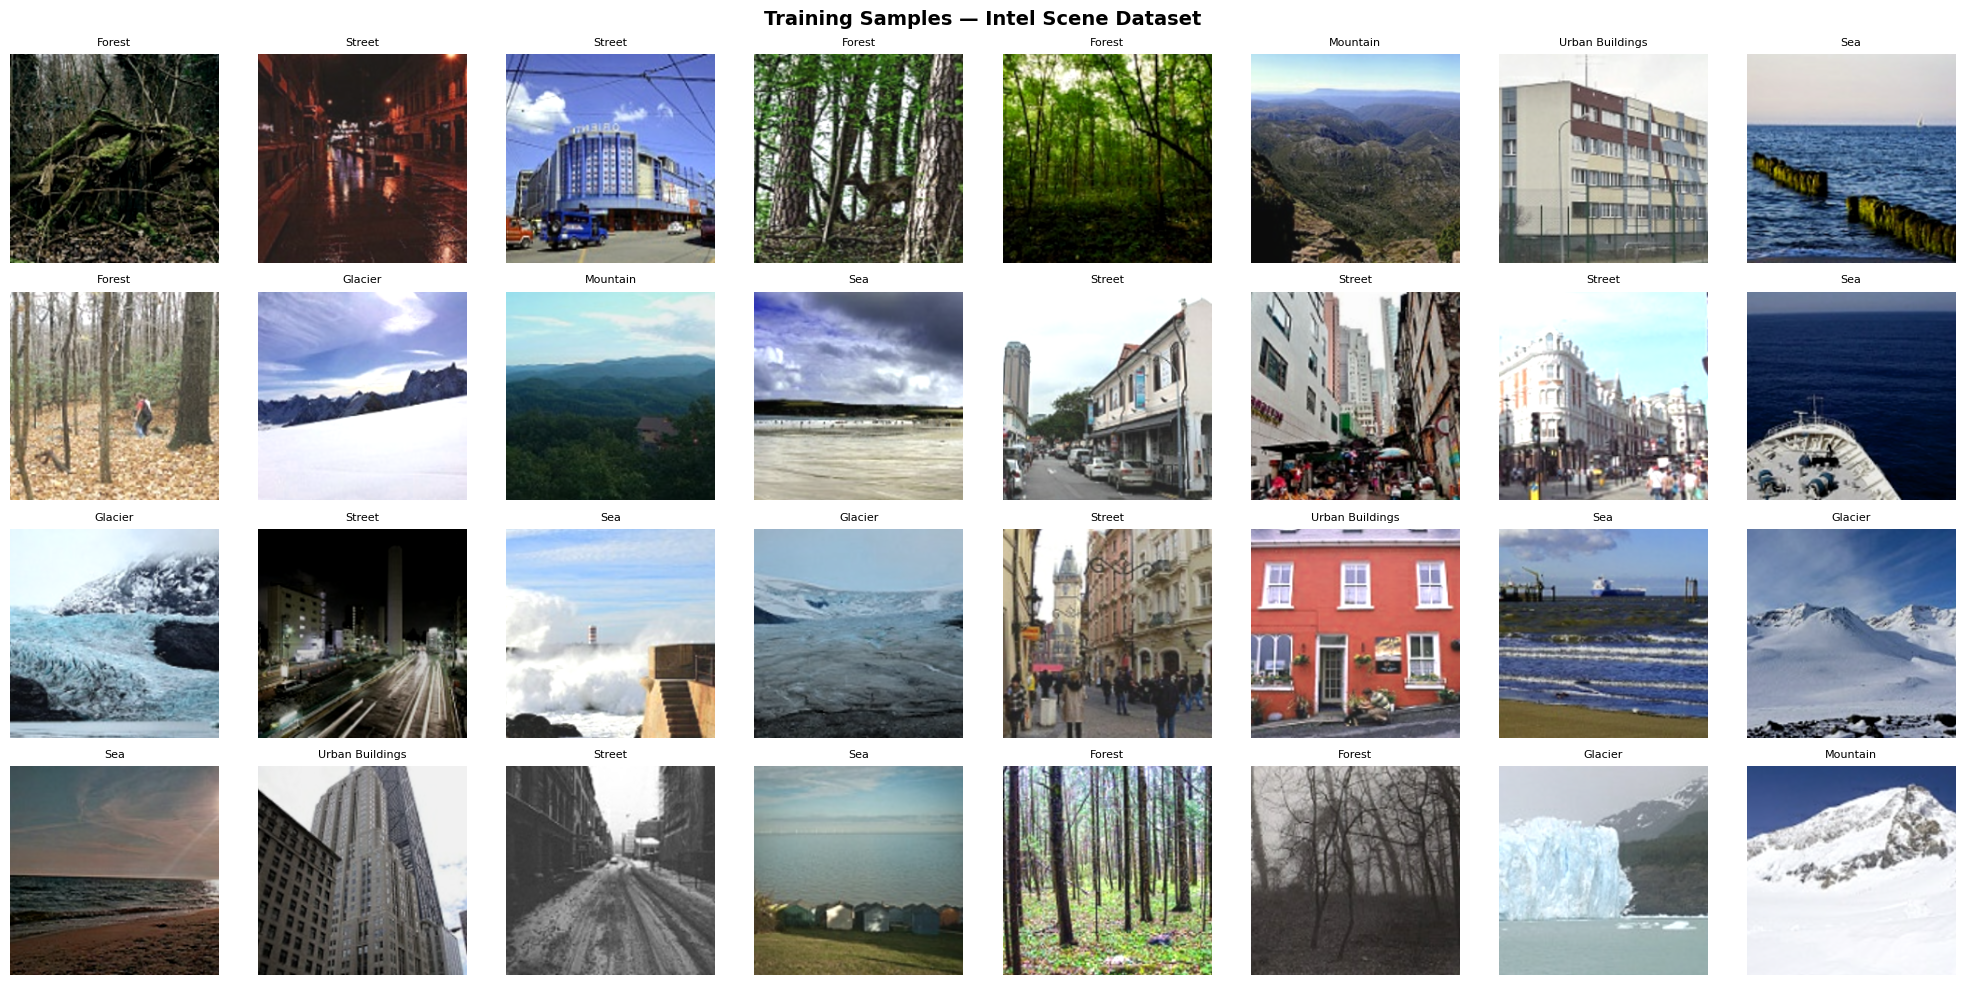

In [ ]:
# Show one batch of training images
sample_images, sample_labels = next(iter(data.train))

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Training Samples — Intel Scene Dataset', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(sample_images): ax.axis('off'); continue
    ax.imshow(sample_images[i].numpy())
    cls_idx = int(tf.argmax(sample_labels[i]))
    ax.set_title(CLASS_DESCRIPTIONS[data.class_names[cls_idx]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{config.output_dir}/training_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 🧠 Model — EfficientNetB0 + Custom Head
**Architecture:**
```
EfficientNetB0 (ImageNet) → GAP → Dense(256) → BN → Dropout(0.4) → Dense(6, Softmax)
```
**Why EfficientNetB0?** — 4× fewer params than VGG16, higher accuracy, 224×224 input is fast even on CPU.

In [ ]:
class EfficientNetBuilder:
    """
    Builds, unfreezes, and compiles the EfficientNetB0 classification model.

    build()              -> assemble model, freeze backbone (Phase 1)
    unfreeze(n)          -> unlock last n layers for Phase 2
    compile(lr)          -> attach Adam + metrics
    trainability_table() -> log per-layer trainability
    """

    def __init__(self, config: Config):
        self.config     = config
        self.model      = None
        self.base_model = None

    def build(self) -> 'EfficientNetBuilder':
        self.base_model = EfficientNetB0(
            weights='imagenet', include_top=False, input_shape=self.config.input_shape
        )
        self.base_model.trainable = False

        inp = tf.keras.Input(shape=self.config.input_shape, name='input')
        x   = self.base_model(inp, training=False)
        x   = layers.GlobalAveragePooling2D(name='gap')(x)
        x   = layers.Dense(self.config.dense_units, activation='relu', name='fc1')(x)
        x   = layers.BatchNormalization(name='bn1')(x)
        x   = layers.Dropout(self.config.dropout_rate, name='dropout')(x)
        out = layers.Dense(self.config.num_classes, activation='softmax', name='predictions')(x)

        self.model = Model(inp, out, name='EfficientNetB0_IntelScenes')
        total     = self.model.count_params()
        trainable = sum(tf.size(w).numpy() for w in self.model.trainable_weights)
        logger.info('Model built — total: %s  trainable: %s', f'{total:,}', f'{trainable:,}')
        return self

    def unfreeze(self, n=None) -> 'EfficientNetBuilder':
        """
        Unlock last n layers of EfficientNetB0 for Phase 2.
        Early layers (edges, textures) stay frozen.
        Later layers (semantics) adapt to scene-specific features.
        """
        n = n or self.config.unfreeze_last
        self.base_model.trainable = True
        for layer in self.base_model.layers[:-n]: layer.trainable = False
        unlocked = sum(1 for l in self.base_model.layers if l.trainable)
        logger.info('Phase 2 — unfrozen %d / %d backbone layers.', unlocked, len(self.base_model.layers))
        return self

    def compile(self, lr: float) -> 'EfficientNetBuilder':
        self.model.compile(
            optimizer = optimizers.Adam(learning_rate=lr),
            loss      = 'categorical_crossentropy',
            metrics   = [
                'accuracy',
                tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc'),
                tf.keras.metrics.AUC(name='auc', multi_label=False),
            ],
        )
        logger.info('Model compiled  lr=%.2e', lr)
        return self

    def trainability_table(self):
        lines = ['', f"  {'Layer':<42} {'Type':<26} Trainable", '  ' + '─'*74]
        for l in self.base_model.layers:
            lines.append(f"  {l.name:<42} {l.__class__.__name__:<26} {'✓ YES' if l.trainable else '✗ frozen'}")
        logger.info('Backbone trainability:%s', '\n'.join(lines))


builder = EfficientNetBuilder(config)
builder.build()
builder.model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


2026-02-22 02:17:33  [INFO]  Model built — total: 4,380,073  trainable: 329,990


Model: "EfficientNetB0_IntelScenes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,073 (16.71 MB)

 Trainable params: 329,990 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 📋 Callbacks

In [ ]:
class CallbackFactory:
    """
    ModelCheckpoint  : saves best model by val_accuracy.
    EarlyStopping    : stops when val_loss stagnates (patience=6).
    ReduceLROnPlateau: halves LR after 3 stagnant epochs (min 1e-7).
    TensorBoard      : summaries per phase.
    CSVLogger        : epoch metrics to CSV.
    """

    @staticmethod
    def get(config: Config, phase: int) -> list:
        out = Path(config.output_dir)
        return [
            callbacks.ModelCheckpoint(
                filepath=str(out / 'best_model.keras'),
                monitor='val_accuracy', save_best_only=True, verbose=0,
            ),
            callbacks.EarlyStopping(
                monitor='val_loss', patience=6, restore_best_weights=True, verbose=1,
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1,
            ),
            callbacks.TensorBoard(
                log_dir=str(out / 'logs' / f'phase{phase}'), histogram_freq=1,
            ),
            callbacks.CSVLogger(str(out / f'phase{phase}_metrics.csv'), append=True),
        ]

print('✅ CallbackFactory defined')

✅ CallbackFactory defined


## 🔒 Phase 1 — Train Classifier Head (Backbone Frozen)
- Backbone: fully frozen (general ImageNet features preserved)
- Learning rate: `1e-3` (safe for fresh Dense layers)
- Goal: converge the new head before touching pre-trained weights

In [ ]:
logger.info('━'*64)
logger.info('PHASE 1  —  Classifier Head Training  (backbone frozen)')
logger.info('━'*64)

builder.compile(lr=config.phase1_lr)
builder.trainability_table()

history1 = builder.model.fit(
    data.train,
    epochs          = config.phase1_epochs,
    validation_data = data.val,
    callbacks       = CallbackFactory.get(config, phase=1),
    verbose         = 1,
)

print('\n✅ Phase 1 complete')
print(f'   Best val_accuracy : {max(history1.history["val_accuracy"]):.4f}')

## 🔓 Phase 2 — Fine-Tune Unfrozen Layers
- Unfreeze **last 30 layers** of EfficientNetB0
- Learning rate: `1e-5` (tiny, to avoid catastrophic forgetting)
- Goal: adapt high-level semantics to scene classification

In [ ]:
logger.info('━'*64)
logger.info('PHASE 2  —  Fine-Tuning  (last %d layers unfrozen)', config.unfreeze_last)
logger.info('━'*64)

builder.unfreeze().compile(lr=config.phase2_lr)
builder.trainability_table()

history2 = builder.model.fit(
    data.train,
    epochs          = config.phase1_epochs + config.phase2_epochs,
    initial_epoch   = config.phase1_epochs,
    validation_data = data.val,
    callbacks       = CallbackFactory.get(config, phase=2),
    verbose         = 1,
)

print('\n✅ Phase 2 complete')
print(f'   Best val_accuracy : {max(history2.history["val_accuracy"]):.4f}')

## 📊 Evaluation & Visualisation

In [ ]:
class Evaluator:
    """
    evaluate               -> dict of all metric values.
    classification_report  -> per-class P / R / F1.
    plot_confusion_matrix  -> normalised seaborn heatmap.
    plot_training_dashboard-> 4-panel figure (accuracy, loss, LR, top-2 acc).
    plot_sample_predictions-> grid of test images (green=correct, red=wrong).
    """

    def __init__(self, config: Config):
        self.config = config
        Path(config.output_dir).mkdir(parents=True, exist_ok=True)

    def evaluate(self, model, dataset) -> dict:
        raw   = model.evaluate(dataset, verbose=0)
        names = [m.name for m in model.metrics]
        result = {k: round(float(v), 4) for k, v in zip(names, raw)}
        logger.info('Evaluation -> %s', result)
        return result

    def classification_report(self, model, dataset, class_names) -> str:
        y_pred, y_true = self._collect(model, dataset)
        full = [CLASS_DESCRIPTIONS.get(c, c) for c in class_names]
        report = classification_report(y_true, y_pred, target_names=full)
        logger.info('Classification Report:\n%s', report)
        return report

    def plot_confusion_matrix(self, model, dataset, class_names, save_path=None) -> np.ndarray:
        y_pred, y_true = self._collect(model, dataset)
        cm     = confusion_matrix(y_true, y_pred, normalize='true')
        labels = [CLASS_DESCRIPTIONS.get(c, c) for c in class_names]
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(cm*100, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'Recall (%)'})
        ax.set_title('Intel Scene — Confusion Matrix', fontsize=13, fontweight='bold', pad=14)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True Label', fontsize=11)
        plt.xticks(rotation=30, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        path = save_path or f'{self.config.output_dir}/confusion_matrix.png'
        plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
        logger.info('Confusion matrix saved -> %s', path)
        return cm

    def plot_training_dashboard(self, h1, h2, save_path=None):
        H1, H2 = h1.history, h2.history
        p1 = len(H1['loss'])
        def mrg(k, fb=None):
            a = H1.get(k, [fb]*p1 if fb is not None else [])
            b = H2.get(k, [fb]*len(H2['loss']) if fb is not None else [])
            return a + b
        acc     = mrg('accuracy');       val_acc  = mrg('val_accuracy')
        loss    = mrg('loss');           val_loss = mrg('val_loss')
        top2    = mrg('top2_acc', None); val_top2 = mrg('val_top2_acc', None)
        lr_v    = (H1.get('lr',[config.phase1_lr]*p1) + H2.get('lr',[config.phase2_lr]*len(H2['loss'])))
        epochs  = list(range(1, len(acc)+1))
        T,V,D   = '#1565C0','#B71C1C','#546E7A'
        def shade(ax):
            ax.axvline(p1+0.5, color=D, ls='--', lw=1.5, label='Phase 1|2')
            ax.axvspan(1, p1+0.5, alpha=0.04, color='steelblue')
            ax.axvspan(p1+0.5, max(epochs), alpha=0.04, color='salmon')
        fig = plt.figure(figsize=(16, 10))
        fig.suptitle('EfficientNetB0  ·  Intel Scenes  ·  Training Dashboard',
                     fontsize=14, fontweight='bold', y=0.98)
        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
        ax1 = fig.add_subplot(gs[0,0])
        ax1.plot(epochs, acc, color=T, lw=2, label='Train')
        ax1.plot(epochs, val_acc, color=V, lw=2, ls='--', label='Val')
        shade(ax1); ax1.set_title('Accuracy'); ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.25); ax1.set_ylim(0, 1.05)
        ax2 = fig.add_subplot(gs[0,1])
        ax2.plot(epochs, loss, color=T, lw=2, label='Train')
        ax2.plot(epochs, val_loss, color=V, lw=2, ls='--', label='Val')
        shade(ax2); ax2.set_title('Loss'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)
        ax3 = fig.add_subplot(gs[1,0])
        ax3.semilogy(epochs, lr_v, color='#4A148C', lw=2)
        shade(ax3); ax3.set_title('Learning Rate (log)'); ax3.grid(True, which='both', alpha=0.25)
        ax4 = fig.add_subplot(gs[1,1])
        if any(v is not None for v in top2):
            ax4.plot(epochs, top2, color=T, lw=2, label='Train Top-2')
            ax4.plot(epochs, val_top2, color=V, lw=2, ls='--', label='Val Top-2')
            ax4.set_title('Top-2 Accuracy'); ax4.legend(fontsize=8)
        else:
            gap = [abs(a-v) for a,v in zip(acc, val_acc)]
            ax4.fill_between(epochs, gap, alpha=0.3, color=V)
            ax4.plot(epochs, gap, color=V, lw=2)
            ax4.set_title('Generalisation Gap')
        shade(ax4); ax4.grid(True, alpha=0.25)
        for ax in [ax1,ax2,ax3,ax4]: ax.set_xlabel('Epoch')
        path = save_path or f'{self.config.output_dir}/training_dashboard.png'
        plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
        logger.info('Training dashboard saved -> %s', path)

    def plot_sample_predictions(self, model, dataset, class_names, n_samples=16, save_path=None):
        images, labels = [], []
        for batch_imgs, batch_labels in dataset.unbatch().take(n_samples):
            images.append(batch_imgs.numpy())
            labels.append(int(np.argmax(batch_labels.numpy())))
        images = np.array(images)
        probs  = model.predict(images, verbose=0)
        preds  = np.argmax(probs, axis=1)
        confs  = np.max(probs, axis=1)
        cols, rows = 4, int(np.ceil(n_samples/4))
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.5))
        fig.suptitle('Sample Predictions — Intel Scene Classification',
                     fontsize=13, fontweight='bold')
        for i, ax in enumerate(axes.flat):
            if i >= n_samples: ax.axis('off'); continue
            ax.imshow(images[i])
            ok    = preds[i] == labels[i]
            color = '#2E7D32' if ok else '#C62828'
            for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(3)
            tn = CLASS_DESCRIPTIONS.get(class_names[labels[i]], class_names[labels[i]])
            pn = CLASS_DESCRIPTIONS.get(class_names[preds[i]],  class_names[preds[i]])
            ax.set_title(f'True: {tn}', fontsize=7.5, pad=2)
            ax.set_xlabel(f'Pred: {pn}  ({confs[i]:.0%})', fontsize=7.5, color=color)
            ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout()
        path = save_path or f'{self.config.output_dir}/sample_predictions.png'
        plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
        logger.info('Sample predictions saved -> %s', path)

    @staticmethod
    def _collect(model, dataset):
        y_true, y_pred = [], []
        for imgs, lbls in dataset:
            preds = model.predict(imgs, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(np.argmax(lbls.numpy(), axis=1))
        return np.array(y_pred), np.array(y_true)


evaluator = Evaluator(config)
print('✅ Evaluator defined')

### 📈 Training Dashboard

In [ ]:
evaluator.plot_training_dashboard(history1, history2)

### 🔲 Confusion Matrix

In [ ]:
metrics = evaluator.evaluate(builder.model, data.val)
print('\n📊 Validation Metrics:')
for k, v in metrics.items(): print(f'   {k:<20} {v}')

In [ ]:
evaluator.plot_confusion_matrix(builder.model, data.val, data.class_names)

### 📋 Classification Report

In [ ]:
report = evaluator.classification_report(builder.model, data.val, data.class_names)
print(report)

### 🖼️ Sample Predictions Grid
🟢 Green border = correct &nbsp; 🔴 Red border = wrong

In [ ]:
evaluator.plot_sample_predictions(builder.model, data.val, data.class_names, n_samples=16)

## 💾 Save Model

In [ ]:
model_path = f'{config.output_dir}/final_model.keras'
builder.model.save(model_path)
print(f'✅ Model saved -> {model_path}')

## 🔍 Single-Image Inference

In [ ]:
def predict_scene(model, img_path: str, img_size=(224, 224)) -> dict:
    """
    Classify a single image and return class probabilities sorted descending.

    Parameters
    ----------
    model    : Trained Keras model
    img_path : Path to a JPG or PNG image
    img_size : Must match training img_size

    Returns
    -------
    dict  e.g. {'forest': 0.8821, 'mountain': 0.0612, ...}
    """
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs  = model.predict(arr, verbose=0)[0]
    result = dict(sorted(
        {cls: round(float(p), 4) for cls, p in zip(CLASSES, probs)}.items(),
        key=lambda x: x[1], reverse=True,
    ))
    top = next(iter(result))

    # Show image with prediction
    img_arr = tf.keras.utils.img_to_array(img) / 255.0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_arr); ax1.axis('off')
    ax1.set_title(f'Predicted: {CLASS_DESCRIPTIONS[top]}\nConfidence: {result[top]:.1%}',
                  fontsize=11, fontweight='bold', color='#1565C0')
    bars = ax2.barh(list(result.keys())[::-1],
                    [result[k] for k in list(result.keys())[::-1]],
                    color=['#1565C0' if k == top else '#90CAF9' for k in list(result.keys())[::-1]])
    ax2.set_xlim(0, 1); ax2.set_xlabel('Probability')
    ax2.set_title('Class Probabilities')
    ax2.grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    return result


# ── Usage ──
# result = predict_scene(builder.model, 'path/to/your/image.jpg')
# print(result)
print('✅ predict_scene() function ready')
print('   Usage: result = predict_scene(builder.model, "your_image.jpg")')

## 🔄 Reload Model (without retraining)

In [ ]:
# Load a previously saved model
# loaded_model = tf.keras.models.load_model('outputs/final_model.keras')
# loaded_config = Config.load('outputs/config.json')
# result = predict_scene(loaded_model, 'scene.jpg')
print('💡 Uncomment the lines above to reload a saved model')